In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error,  mean_absolute_error, root_mean_squared_error

import pickle

random_state = 42


In [488]:
df = pd.read_csv('data/boston_cleaned.csv')
df_o = pd.read_csv('data/boston.csv')
df.shape, df_o.shape

((465, 15), (506, 14))

In [489]:
df.shape
df.drop(columns=['Unnamed: 0'], inplace=True)
df_o['MEDV']
# df =df.join(df_o[['MEDV']], how='inner')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,0,0.538,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,24.0
1,-0.417339,-0.487722,-0.593381,0,0.469,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,21.6
2,-0.417342,-0.487722,-0.593381,0,0.469,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,34.7
3,-0.416750,-0.487722,-1.306878,0,0.458,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,33.4
4,-0.412482,-0.487722,-1.306878,0,0.458,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,36.2


In [490]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['MEDV']), df['MEDV'], test_size=0.2, random_state=random_state)

In [491]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((372, 13), (93, 13), (372,), (93,))

In [492]:
model = MLPRegressor(hidden_layer_sizes=(8,8),
                    activation='relu',
                     solver='sgd', 
                     verbose=True,
                     validation_fraction=0.1,
                     early_stopping=True,
                     n_iter_no_change=30,
                     max_iter=1000, 

                     learning_rate_init=0.001,
                     learning_rate='adaptive',

                    #  batch_size=10,
                     random_state=random_state)

In [493]:
model.fit(X_train, y_train)

Iteration 1, loss = 282.18528547
Validation score: -6.100693
Iteration 2, loss = 269.04143098
Validation score: -5.612877
Iteration 3, loss = 250.12689271
Validation score: -4.972776
Iteration 4, loss = 224.12548161
Validation score: -4.048714
Iteration 5, loss = 186.43189060
Validation score: -2.576863
Iteration 6, loss = 126.69502924
Validation score: -0.417014
Iteration 7, loss = 49.67226313
Validation score: 0.628962
Iteration 8, loss = 28.10819407
Validation score: -0.037756
Iteration 9, loss = 37.19560286
Validation score: 0.531980
Iteration 10, loss = 18.75515905
Validation score: 0.617207
Iteration 11, loss = 15.53953153
Validation score: 0.636236
Iteration 12, loss = 14.08255771
Validation score: 0.742992
Iteration 13, loss = 11.11431027
Validation score: 0.831119
Iteration 14, loss = 8.72106670
Validation score: 0.829780
Iteration 15, loss = 8.35646594
Validation score: 0.812685
Iteration 16, loss = 8.32621038
Validation score: 0.822331
Iteration 17, loss = 7.88538100
Validat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'adaptive'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",30
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regulari

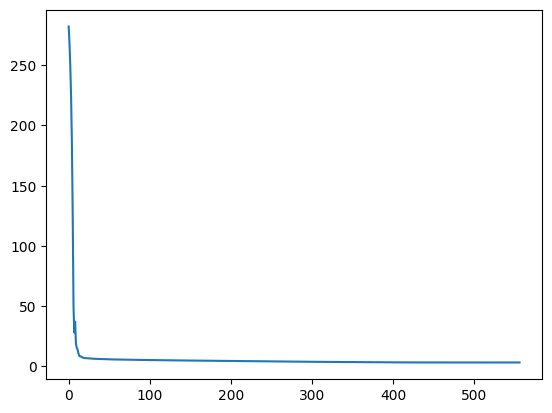

In [494]:
plt.plot(model.loss_curve_)

In [495]:
prediction_no_scale = model.predict(X_test)
model.score(X_test, y_test)

0.8568629483347369

In [496]:
std_scaler = StandardScaler()
target = std_scaler.fit_transform(df['MEDV'].values.reshape(-1, 1)).ravel()
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(df.drop(columns=['MEDV']), target, test_size=0.2, random_state=random_state)


In [497]:
model_scale = MLPRegressor(hidden_layer_sizes=(16,8),
                    activation='relu',
                     solver='adam', 
                     verbose=True,
                     validation_fraction=0.1,
                     early_stopping=True,
                     n_iter_no_change=30,
                     max_iter=1000, 

                     learning_rate_init=0.001,
                     learning_rate='adaptive',

                    #  batch_size=10,
                     random_state=random_state)

In [498]:
model_scale.fit(X_train_scaled, y_train_scaled)

Iteration 1, loss = 0.79925753
Validation score: -0.490448
Iteration 2, loss = 0.76865549
Validation score: -0.437845
Iteration 3, loss = 0.73977774
Validation score: -0.386176
Iteration 4, loss = 0.71243398
Validation score: -0.340430
Iteration 5, loss = 0.68724331
Validation score: -0.297248
Iteration 6, loss = 0.66435309
Validation score: -0.255900
Iteration 7, loss = 0.64233756
Validation score: -0.214535
Iteration 8, loss = 0.62096149
Validation score: -0.174654
Iteration 9, loss = 0.60088312
Validation score: -0.135617
Iteration 10, loss = 0.58011958
Validation score: -0.098160
Iteration 11, loss = 0.55959209
Validation score: -0.063535
Iteration 12, loss = 0.54034966
Validation score: -0.030982
Iteration 13, loss = 0.52034076
Validation score: -0.000900
Iteration 14, loss = 0.50185691
Validation score: 0.026845
Iteration 15, loss = 0.48430308
Validation score: 0.050757
Iteration 16, loss = 0.46662719
Validation score: 0.070875
Iteration 17, loss = 0.45063554
Validation score: 0.

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'adaptive'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",30
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regula

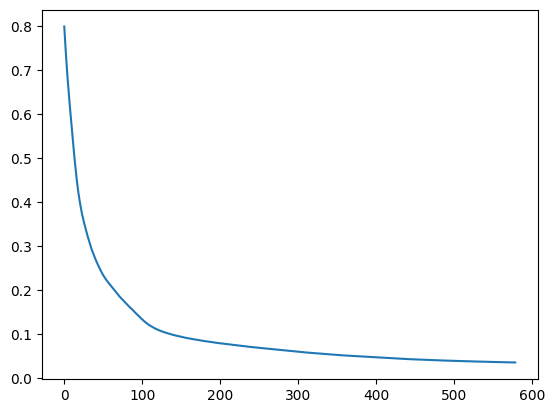

In [499]:
plt.plot(model_scale.loss_curve_)

In [ ]:
predictions = model_scale.predict(X_test_scaled)

score = model_scale.score(X_test_scaled, y_test_scaled)

std_test = np.std(y_test_scaled)
std_pred = np.std(predictions)

mse = mean_squared_error(y_test_scaled, predictions)
mae = mean_absolute_error(y_test_scaled, predictions)
rmse = root_mean_squared_error(y_test_scaled    , predictions)




mse_no_scale = mean_squared_error(y_test, prediction_no_scale)
mae_no_scale = mean_absolute_error(y_test, prediction_no_scale)
rmse_no_scale = root_mean_squared_error(y_test, prediction_no_scale)

score, mse, mae, rmse, std_test, std_pred,mse_no_scale, mae_no_scale, rmse_no_scale

(0.8415594883194066,
 0.16778144495627992,
 0.25592356002996675,
 0.4096113340183349,
 np.float64(1.0290556156835826),
 np.float64(0.8873176362634606),
 11.299301415752122,
 2.2876073114337143,
 3.3614433530482293)

In [511]:
predictions = predictions.reshape(-1, 1)
p_sc = std_scaler.inverse_transform(predictions).ravel()[:10], 
p_sc_t =std_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()[:10]
print(np.round(p_sc, 1), '\n', np.round(p_sc_t, 2))

[[35.5 21.6 15.2 17.7 17.8 33.2 35.1 19.9 15.1 25.3]] 
 [35.4 21.4 13.1 18.3 16.2 31.7 32.7 18.9 13.6 23.7]
